# Census-tract test of the mental distress formula

A **census tract** is a neighbourhood-sized area defined by the U.S. Census Bureau, usually 1,200–8,000 people. Every county is split into tracts (Baltimore city has about 200), and the U.S. has about 84,000. CDC PLACES publishes the same measures for every tract as it does for counties and states.

This notebook asks two questions:

1. **Does the poster formula still work at neighbourhood level?** It was fit on 52 state averages and is applied here, unchanged, to 60,000+ tracts.
2. **If it doesn't fit well, what change fixes it?** Any change must keep the same two inputs (depression and financial threat) and stay a formula you can write on one line.

Data: CDC PLACES, Census Tract Data, 2025 release (`cwsq-ngmh`, BRFSS 2023), loaded directly from the CDC API.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from urllib.parse import urlencode
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

## 1. Load tract data

In [2]:
MEASURES = {
    "Frequent mental distress among adults": "distress",
    "Depression among adults": "depression",
    "Housing insecurity in the past 12 months among adults": "housing",
    "Utility services shut-off threat in the past 12 months among adults": "utility",
    "Food insecurity in the past 12 months among adults": "food",
    "Received food stamps in the past 12 months among adults": "stamps",
}
FINANCIAL = ["housing", "utility", "food", "stamps"]

def load_places(dataset_id, fields, page_size=200000):
    # Socrata pages results, so keep requesting until a short page comes back
    measure_list = ",".join(f"'{m}'" for m in MEASURES)
    pages, offset = [], 0
    while True:
        query = urlencode({
            "$select": fields,
            "$where": f"measure in({measure_list}) AND data_value_type='Crude prevalence'",
            "$order": "locationid,measure",
            "$limit": page_size,
            "$offset": offset,
        })
        page = pd.read_csv(f"https://chronicdata.cdc.gov/resource/{dataset_id}.csv?{query}",
                           dtype={"locationid": str, "countyfips": str})
        pages.append(page)
        if len(page) < page_size:
            break
        offset += page_size
    raw = pd.concat(pages, ignore_index=True)
    raw = raw[raw["stateabbr"] != "US"]
    raw["measure"] = raw["measure"].map(MEASURES)
    return raw

def wide_table(raw, index):
    wide = raw.pivot_table(index=index, columns="measure", values="data_value").reset_index()
    wide["financial_threat"] = wide[FINANCIAL].mean(axis=1, skipna=False)
    return wide.dropna(subset=["distress", "depression", "financial_threat"])

tract_raw = load_places("cwsq-ngmh", "stateabbr,countyfips,countyname,locationid,measure,data_value")
tracts = wide_table(tract_raw, ["locationid", "stateabbr", "countyfips", "countyname"])

print(f"Rows downloaded: {len(tract_raw):,}")
print(f"Tracts in the data: {tract_raw['locationid'].nunique():,}")
print(f"Tracts with all six measures: {len(tracts):,} in {tracts['countyfips'].nunique():,} counties and {tracts['stateabbr'].nunique()} states")
print(f"Distress ranges from {tracts['distress'].min()}% to {tracts['distress'].max()}% (SD {tracts['distress'].std():.2f})")

Rows downloaded: 399,306
Tracts in the data: 78,815
Tracts with all six measures: 60,419 in 2,299 counties and 40 states
Distress ranges from 5.6% to 38.2% (SD 3.20)


## 2. Test the poster formula, unchanged

`distress = 6.163 + 0.313 · depression + 0.277 · financial_threat`

For comparison, the same straight-line model is also refit on tracts and scored **out-of-state**: each tract is predicted by a model that never saw any tract from its state.

In [3]:
POSTER = {"intercept": 6.162857696868079, "depression": 0.31342386, "financial_threat": 0.27670656}

def poster_formula(d):
    return POSTER["intercept"] + POSTER["depression"] * d["depression"] + POSTER["financial_threat"] * d["financial_threat"]

def accuracy(actual, predicted):
    err = predicted - actual
    return pd.Series({
        "R2": r2_score(actual, predicted),
        "RMSE (pp)": mean_squared_error(actual, predicted) ** 0.5,
        "mean error": err.mean(),
        "% within ±1 pp": (err.abs() <= 1).mean() * 100,
        "% within ±2 pp": (err.abs() <= 2).mean() * 100,
    })

state_folds = GroupKFold(n_splits=5)
y = tracts["distress"]
tracts["poster"] = poster_formula(tracts)
tracts["linear refit"] = cross_val_predict(LinearRegression(), tracts[["depression", "financial_threat"]], y,
                                           cv=state_folds, groups=tracts["stateabbr"])

pd.DataFrame({
    "Poster formula (unchanged)": accuracy(y, tracts["poster"]),
    "Straight line refit on tracts (out-of-state)": accuracy(y, tracts["linear refit"]),
}).T.round(3)

,R2,RMSE (pp),mean error,% within ±1 pp,% within ±2 pp
Poster formula (unchanged),0.823,1.346,0.061,60.742,89.258
Straight line refit on tracts (out-of-state),0.834,1.304,0.012,61.486,89.373


The formula transfers well (R² ≈ 0.82), and refitting the straight line barely helps. So the problem isn't the coefficients; it's the **shape**. Section 3 shows this.

## 3. Where the straight line goes wrong

Tracts are split into ten equal-sized groups by financial threat. For each group we plot the average error (predicted − actual). A formula with the right shape stays near zero across all ten groups.

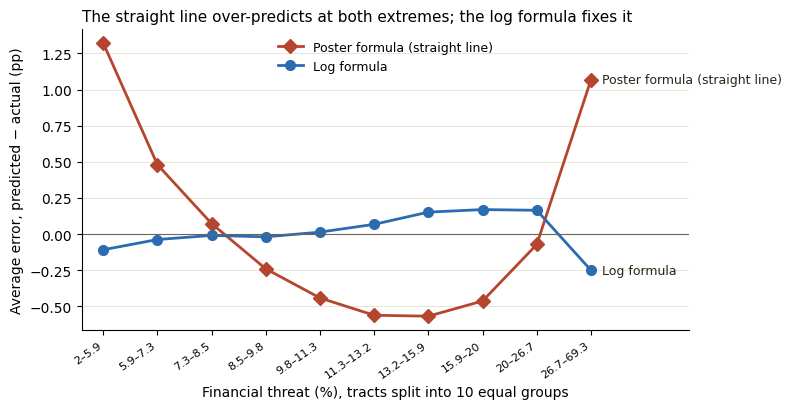

In [4]:
FEATURES_LOG = lambda d: pd.DataFrame({"depression": d["depression"], "log_financial_threat": np.log(d["financial_threat"])})
tracts["log formula"] = cross_val_predict(LinearRegression(), FEATURES_LOG(tracts), y,
                                          cv=state_folds, groups=tracts["stateabbr"])

decile = pd.qcut(tracts["financial_threat"], 10, labels=False) + 1
bias = pd.DataFrame({
    "Poster formula (straight line)": (tracts["poster"] - y).groupby(decile).mean(),
    "Log formula": (tracts["log formula"] - y).groupby(decile).mean(),
})
decile_range = tracts.groupby(decile)["financial_threat"].agg(["min", "max"]).round(1)

fig, ax = plt.subplots(figsize=(8, 4.2))
styles = {"Poster formula (straight line)": ("#b5452f", "D"), "Log formula": ("#2b6cb0", "o")}
for name, (color, marker) in styles.items():
    ax.plot(bias.index, bias[name], color=color, marker=marker, linewidth=2, markersize=7, label=name)
    ax.annotate(name, (10, bias[name].iloc[-1]), xytext=(8, 0), textcoords="offset points",
                va="center", fontsize=9, color="#2a2418")
ax.axhline(0, color="#6b6457", linewidth=0.8)
ax.set_xticks(bias.index)
ax.set_xticklabels([f"{lo:g}–{hi:g}" for lo, hi in decile_range.values], rotation=35, ha="right", fontsize=8)
ax.set_xlabel("Financial threat (%), tracts split into 10 equal groups")
ax.set_ylabel("Average error, predicted − actual (pp)")
ax.set_title("The straight line over-predicts at both extremes; the log formula fixes it", loc="left", fontsize=11)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.grid(axis="y", color="#e6e0d4", linewidth=0.6); ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=9, loc="upper center")
ax.set_xlim(0.6, 11.8)
plt.tight_layout()
plt.show()

The straight line over-predicts distress in the least deprived neighbourhoods and again in the most deprived ones. Distress rises fast as hardship goes from very low to moderate, then rises more slowly. That is a **diminishing-returns** curve, and the natural fix is to use the logarithm of financial threat.

## 4. Choosing the change

Several candidate formulas, all scored out-of-state on the same folds. Gradient boosting is a flexible black-box model, included only as an upper bound for how much any reshaping of these two inputs can gain.

In [5]:
d, f = tracts["depression"], tracts["financial_threat"]
candidates = {
    "Straight line (refit)": pd.DataFrame({"dep": d, "fin": f}),
    "Depression + log(financial threat)": pd.DataFrame({"dep": d, "log_fin": np.log(f)}),
    "Quadratic in both": pd.DataFrame({"dep": d, "dep2": d**2, "fin": f, "fin2": f**2}),
    "Quadratic + interaction": pd.DataFrame({"dep": d, "dep2": d**2, "fin": f, "fin2": f**2, "dep_x_fin": d * f}),
}
rows = {}
for name, X in candidates.items():
    rows[name] = accuracy(y, cross_val_predict(LinearRegression(), X, y, cv=state_folds, groups=tracts["stateabbr"]))
rows["Gradient boosting (black box, upper bound)"] = accuracy(
    y, cross_val_predict(HistGradientBoostingRegressor(random_state=42), candidates["Straight line (refit)"], y,
                         cv=state_folds, groups=tracts["stateabbr"]))
pd.DataFrame(rows).T.round(3)

,R2,RMSE (pp),mean error,% within ±1 pp,% within ±2 pp
Straight line (refit),0.834,1.304,0.012,61.486,89.373
Depression + log(financial threat),0.868,1.162,0.014,68.013,93.164
Quadratic in both,0.857,1.210,0.036,63.842,91.597
Quadratic + interaction,0.860,1.196,0.034,64.559,91.863
"Gradient boosting (black box, upper bound)",0.869,1.156,0.049,67.802,92.843


**Depression + log(financial threat)** matches the black-box model while staying a two-term formula, so it is the change we adopt. The quadratic versions do worse and are harder to interpret.

In [6]:
log_model = LinearRegression().fit(FEATURES_LOG(tracts), y)
b0, b_dep, b_log = log_model.intercept_, *log_model.coef_
print("New formula (fit on all tracts):")
print(f"  distress = {b0:.3f} + {b_dep:.3f} · depression + {b_log:.3f} · ln(financial_threat)")
print()
print(f"Reading it: each 1-point rise in depression adds {b_dep:.2f} pp of distress.")
print(f"            each DOUBLING of financial threat adds {b_log * np.log(2):.2f} pp of distress")
print(f"            (going from 5% to 10% adds as much as going from 20% to 40%).")

def log_formula(d):
    return b0 + b_dep * d["depression"] + b_log * np.log(d["financial_threat"])

New formula (fit on all tracts):
  distress = -1.808 + 0.376 · depression + 4.209 · ln(financial_threat)

Reading it: each 1-point rise in depression adds 0.38 pp of distress.
            each DOUBLING of financial threat adds 2.92 pp of distress
            (going from 5% to 10% adds as much as going from 20% to 40%).


## 5. Does the new formula also work for counties?

The log formula was fit only on tracts. Here it is applied, without refitting, to the 2023 county data used in `County_Analysis.ipynb`, next to the original poster formula.

In [7]:
county_raw = load_places("swc5-untb", "stateabbr,locationname,locationid,measure,data_value")
counties = wide_table(county_raw, ["locationid", "stateabbr", "locationname"])
print(f"Counties with all six measures: {len(counties):,}")

pd.DataFrame({
    "Poster formula": accuracy(counties["distress"], poster_formula(counties)),
    "Log formula from tracts (no refit)": accuracy(counties["distress"], log_formula(counties)),
}).T.round(3)

Counties with all six measures: 2,299


,R2,RMSE (pp),mean error,% within ±1 pp,% within ±2 pp
Poster formula,0.787,0.915,-0.253,71.988,97.521
Log formula from tracts (no refit),0.817,0.847,0.139,77.642,98.086


## 6. Baltimore city, neighbourhood by neighbourhood

Baltimore city (county FIPS 24510) is home to Morgan State. The straight-line formula struggles most in cities, where neighbourhoods range from very affluent to very deprived within a few miles.

In [8]:
balt = tracts[tracts["countyfips"] == "24510"].copy()
print(f"Baltimore city tracts: {len(balt)}")
pd.DataFrame({
    "Poster formula": accuracy(balt["distress"], balt["poster"]),
    "Log formula (out-of-state)": accuracy(balt["distress"], balt["log formula"]),
}).T.round(3)

Baltimore city tracts: 198


,R2,RMSE (pp),mean error,% within ±1 pp,% within ±2 pp
Poster formula,0.650,1.781,1.396,34.848,72.222
Log formula (out-of-state),0.823,1.266,0.875,46.465,90.909


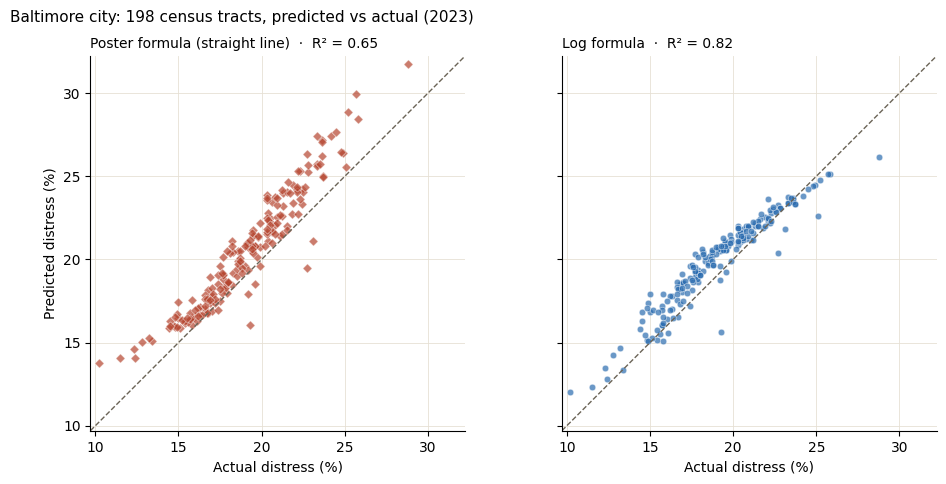

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.8), sharex=True, sharey=True)
lo = balt[["distress", "poster", "log formula"]].min().min() - 0.5
hi = balt[["distress", "poster", "log formula"]].max().max() + 0.5
panels = [("poster", "Poster formula (straight line)", "#b5452f", "D"),
          ("log formula", "Log formula", "#2b6cb0", "o")]
for ax, (col, title, color, marker) in zip(axes, panels):
    r2 = r2_score(balt["distress"], balt[col])
    ax.scatter(balt["distress"], balt[col], s=22, color=color, marker=marker, alpha=0.7, edgecolors="white", linewidths=0.4)
    ax.plot([lo, hi], [lo, hi], color="#6b6457", linestyle="--", linewidth=1)
    ax.set_title(f"{title}  ·  R² = {r2:.2f}", loc="left", fontsize=10)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
    ax.set_xlabel("Actual distress (%)")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.grid(color="#e6e0d4", linewidth=0.6); ax.set_axisbelow(True)
axes[0].set_ylabel("Predicted distress (%)")
fig.suptitle(f"Baltimore city: {len(balt)} census tracts, predicted vs actual (2023)", x=0.02, ha="left", fontsize=11)
plt.tight_layout()
plt.show()

## 7. Does it explain differences *within* a county?

A formula can look good across the country just by getting regional averages right. The stricter test: subtract each county's average, then check whether the formula explains which neighbourhoods inside the same county are worse off.

In [10]:
def within_county_r2(pred):
    g = tracts.groupby("countyfips")
    actual_dev = y - g["distress"].transform("mean")
    pred_dev = pred - pred.groupby(tracts["countyfips"]).transform("mean")
    return 1 - ((actual_dev - pred_dev) ** 2).sum() / (actual_dev ** 2).sum()

print(f"Within-county R², poster formula: {within_county_r2(tracts['poster']):.3f}")
print(f"Within-county R², log formula:    {within_county_r2(tracts['log formula']):.3f}")

Within-county R², poster formula: 0.851
Within-county R², log formula:    0.910


## 8. Findings

1. **The poster formula works at neighbourhood level.** Applied unchanged to 60,419 census tracts, it gets R² = 0.82, with 61% of tracts within ±1 point and 89% within ±2. Tracts vary more than counties (SD 3.2 vs 2.0 pp), so the typical miss is larger (1.35 pp), but the share of variation explained is higher.
2. **The straight line has the wrong shape.** It over-predicts distress in the least deprived and the most deprived neighbourhoods. Refitting the coefficients doesn't fix this (R² 0.83); changing the shape does.
3. **The change: use the log of financial threat.**
   `distress = −1.808 + 0.376 · depression + 4.209 · ln(financial_threat)`
   Out-of-state R² rises to 0.87, the share within ±1 point rises from 61% to 68%, and the systematic error almost disappears. It matches a black-box gradient-boosting model (0.869), so there is little left to gain from these two inputs.
4. **Interpretation: diminishing returns.** Each doubling of financial threat adds about 2.9 points of distress. Going from 5% to 10% hardship matters as much as going from 20% to 40%.
5. **The improvement carries to counties.** Fit only on tracts and applied to 2,299 counties with no refitting, the log formula beats the poster formula (R² 0.82 vs 0.79; 78% vs 72% within ±1 point).
6. **Biggest gain in Baltimore city.** Across 198 tracts, R² goes from 0.65 to 0.82, and the share within ±2 points from 72% to 91%. Both formulas still over-predict Baltimore on average (+0.9 pp with the log formula), so something specific to the city keeps distress lower than its hardship and depression levels would suggest.
7. **It explains differences inside counties too.** After removing each county's average, the log formula explains 91% of the remaining tract-to-tract variation (poster formula: 85%). The formula isn't just getting regional averages right; it sorts neighbourhoods within the same county.

## Limitations

- **Tract values are model-based estimates, more so than counties.** CDC estimates every tract from BRFSS responses combined with that tract's demographics (multilevel regression and post-stratification). Very few survey respondents live in any single tract, so tract values lean heavily on that model. Part of the high R² comes from depression, financial threat and distress all being estimated from the same demographic inputs. Treat tract R² as an upper bound, and don't present it as independent confirmation of the county result.
- **Ecological data.** These are neighbourhood rates, not individuals, so the results don't show cause and effect for any one person.
- **Same 40-state coverage** as the county analysis, because the financial-hardship questions were only asked in 40 states in 2023.
- **One year (2023).** The log formula hasn't yet been checked on 2022 tract data.
